<a href="https://colab.research.google.com/github/soyeonimu/Codeit_Sprint/blob/main/%5B%EC%8A%A4%ED%94%84%EB%A6%B0%ED%8A%B8%E1%84%86%E1%85%B5%E1%84%89%E1%85%A7%E1%86%AB%5D10_3%E1%84%90%E1%85%B5%E1%86%B7_%E1%84%80%E1%85%B5%E1%86%B7%E1%84%89%E1%85%A9%E1%84%8B%E1%85%A7%E1%86%AB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***
# 스프린터 미션 10
***

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
import numpy as np
sns.set_theme(style="whitegrid", palette='BrBG')

In [ ]:
df = pd.read_csv('bakery_sales_revised.csv')
df

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,10/30/2016 9:58,morning,weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
2,2,Scandinavian,10/30/2016 10:05,morning,weekend
3,3,Hot chocolate,10/30/2016 10:07,morning,weekend
4,3,Jam,10/30/2016 10:07,morning,weekend
...,...,...,...,...,...
20502,9682,Coffee,4/9/2017 14:32,afternoon,weekend
20503,9682,Tea,4/9/2017 14:32,afternoon,weekend
20504,9683,Coffee,4/9/2017 14:57,afternoon,weekend
20505,9683,Pastry,4/9/2017 14:57,afternoon,weekend


In [ ]:
df.dtypes

Transaction         int64
Item               object
date_time          object
period_day         object
weekday_weekend    object
dtype: object

In [ ]:
df.isna().sum()

Transaction        0
Item               0
date_time          0
period_day         0
weekday_weekend    0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(1620)

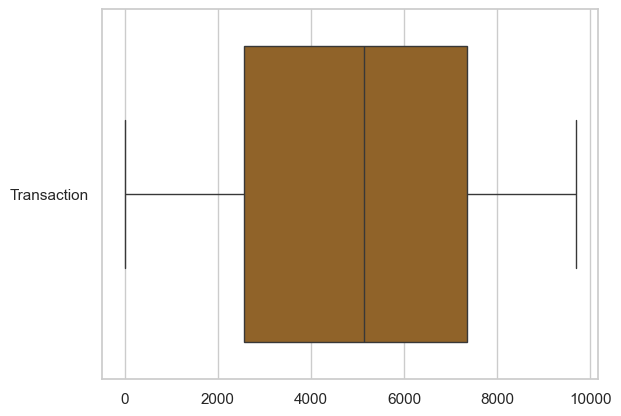

In [ ]:
sns.boxplot(df, orient='h')
plt.show()

In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=False).dt.strftime('%Y-%m-%d %H:%M').astype('datetime64[ns]')

***
# EDA
***

> # Transaction

In [ ]:
df.sort_values(by='Transaction')

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,2016-10-30 09:58:00,morning,weekend
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend
5,3,Cookies,2016-10-30 10:07:00,morning,weekend
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend
...,...,...,...,...,...
20502,9682,Coffee,2017-04-09 14:32:00,afternoon,weekend
20503,9682,Tea,2017-04-09 14:32:00,afternoon,weekend
20504,9683,Coffee,2017-04-09 14:57:00,afternoon,weekend
20505,9683,Pastry,2017-04-09 14:57:00,afternoon,weekend


- `개별상품` = `데이터 한줄`
- `총 매출건수`는 `9684`개

> # Item

In [ ]:
df['Item'].unique()

array(['Bread', 'Scandinavian', 'Hot chocolate', 'Jam', 'Cookies',
       'Muffin', 'Coffee', 'Pastry', 'Medialuna', 'Tea', 'Tartine',
       'Basket', 'Mineral water', 'Farm House', 'Fudge', 'Juice',
       "Ella's Kitchen Pouches", 'Victorian Sponge', 'Frittata',
       'Hearty & Seasonal', 'Soup', 'Pick and Mix Bowls', 'Smoothies',
       'Cake', 'Mighty Protein', 'Chicken sand', 'Coke',
       'My-5 Fruit Shoot', 'Focaccia', 'Sandwich', 'Alfajores', 'Eggs',
       'Brownie', 'Dulce de Leche', 'Honey', 'The BART', 'Granola',
       'Fairy Doors', 'Empanadas', 'Keeping It Local', 'Art Tray',
       'Bowl Nic Pitt', 'Bread Pudding', 'Adjustment', 'Truffles',
       'Chimichurri Oil', 'Bacon', 'Spread', 'Kids biscuit', 'Siblings',
       'Caramel bites', 'Jammie Dodgers', 'Tiffin', 'Olum & polenta',
       'Polenta', 'The Nomad', 'Hack the stack', 'Bakewell',
       'Lemon and coconut', 'Toast', 'Scone', 'Crepes', 'Vegan mincepie',
       'Bare Popcorn', 'Muesli', 'Crisps', 'Pintxos', 

In [ ]:
df[df['Item'] == 'Adjustment']

,Transaction,Item,date_time,period_day,weekday_weekend
1927,938,Adjustment,2016-11-09 19:49:00,evening,weekday


상품별 주문건수 비율 계산

In [ ]:
# 상품별 트랜젝션 합계
product_sales = df.groupby('Item')['Transaction'].sum().reset_index()

In [ ]:
# 전체 매출
total_sales = product_sales['Transaction'].sum()

In [ ]:
# 각 상품별 비율
product_sales['Sales Percentage'] = (product_sales['Transaction'] / total_sales) * 100
product_sales

,Item,Transaction,Sales Percentage
0,Adjustment,938,0.000919
1,Afternoon with the baker,286028,0.280291
2,Alfajores,1512575,1.482234
3,Argentina Night,64153,0.062866
4,Art Tray,140877,0.138051
...,...,...,...
89,Tshirt,126226,0.123694
90,Valentine's card,79821,0.078220
91,Vegan Feast,135944,0.133217
92,Vegan mincepie,223407,0.218926


In [ ]:
product_sales.sort_values(by='Sales Percentage',ascending=False)

,Item,Transaction,Sales Percentage
23,Coffee,27084057,26.540772
11,Bread,16213533,15.888302
83,Tea,7030856,6.889823
15,Cake,5932362,5.813363
73,Sandwich,4344466,4.257319
...,...,...,...
36,Fairy Doors,1666,0.001633
5,Bacon,1248,0.001223
0,Adjustment,938,0.000919
84,The BART,475,0.000465


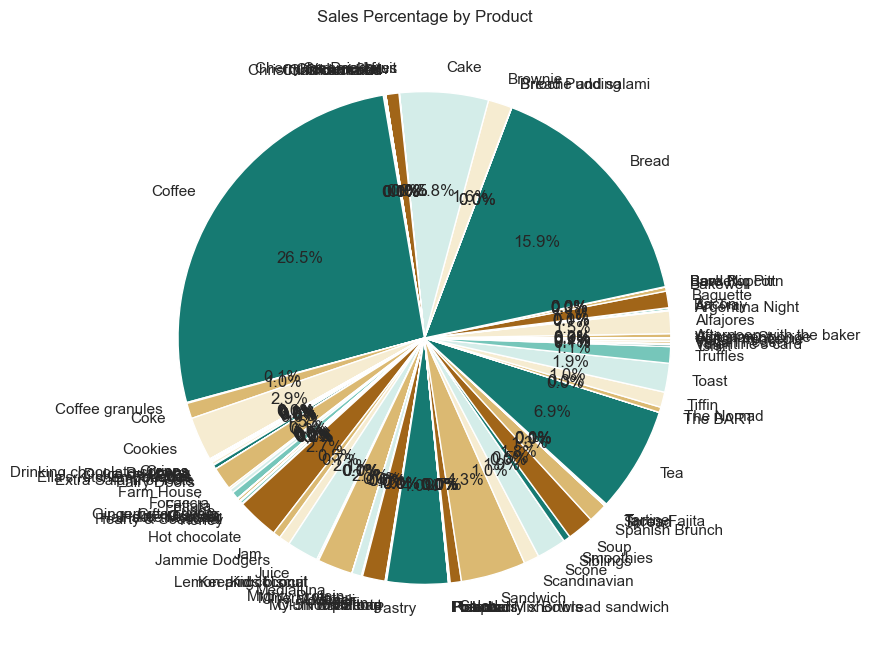

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(product_sales['Sales Percentage'], labels=product_sales['Item'], autopct='%1.1f%%')
plt.title('Sales Percentage by Product')
plt.show()

- 커피, 빵이 제일 많다
- 카테고리화하면 더 좋을것같다

In [ ]:
product_categories = {
    # Beverages (음료)
    'Coffee': 'Beverages', 'Coffee granules': 'Beverages', 'Coke': 'Beverages',
    'Hot chocolate': 'Beverages', 'Juice': 'Beverages', 'Mineral water': 'Beverages',
    'Smoothies': 'Beverages', 'Tea': 'Beverages',

    # Bakery (베이커리, 디저트, 페이스트리, 케이크, 빵류 등)
    'Baguette': 'Bakery', 'Bakewell': 'Bakery', 'Bread': 'Bakery', 'Bread Pudding': 'Bakery',
    'Brioche and salami': 'Bakery', 'Focaccia': 'Bakery', 'Scone': 'Bakery', 'Toast': 'Bakery',
    'Tartine': 'Bakery', 'Victorian Sponge': 'Bakery', 'Cake': 'Bakery', 'Muffin': 'Bakery',
    'Raspberry shortbread sandwich': 'Bakery', 'Tiffin': 'Bakery', 'Pastry': 'Bakery',
    'Mighty Protein': 'Bakery', 'Vegan Feast': 'Bakery', 'Vegan mincepie': 'Bakery',
    'Medialuna': 'Bakery', 'Panatone': 'Bakery', 'Polenta': 'Bakery', 'Farm House': 'Bakery',


    # Food (식사류)
    'Frittata': 'Food', 'Soup': 'Food', 'Salad': 'Food', 'Spanish Brunch': 'Food',
    'Tacos-Fajita': 'Food', 'The BART': 'Food', 'The Nomad': 'Food', 'Empanadas': 'Food',
    'Chicken Stew': 'Food', 'Chicken sand': 'Food', 'Spread': 'Food', 'Olum & polenta': 'Food',


    # Snacks (스낵류)
    'Alfajores': 'Snacks', 'Bacon': 'Snacks', 'Bare Popcorn': 'Snacks', 'Brownie': 'Snacks',
    'Caramel bites': 'Snacks', 'Cherry me Dried fruit': 'Snacks', 'Chocolates': 'Snacks',
    'Cookies': 'Snacks', 'Crepes': 'Snacks', 'Crisps': 'Snacks', 'Drinking chocolate spoons': 'Snacks',
    'Fudge': 'Snacks', 'Gingerbread syrup': 'Snacks', 'Jam': 'Snacks', 'Jammie Dodgers': 'Snacks',
    'Kids biscuit': 'Snacks', 'Lemon and coconut': 'Snacks', 'Raw bars': 'Snacks', 'Sandwich': 'Snacks',
    'Scone': 'Snacks', 'Truffles': 'Snacks','Granola': 'Snacks', 'Muesli': 'Snacks', 'My-5 Fruit Shoot': 'Snacks',

    # Dining Sets & Accessories
    'Art Tray': 'Dining Sets & Accessories', 'Basket': 'Dining Sets & Accessories',
    'Bowl Nic Pitt': 'Dining Sets & Accessories', 'Pick and Mix Bowls': 'Dining Sets & Accessories',
    'Tshirt': 'Dining Sets & Accessories',

    # Events & Themes
    'Afternoon with the baker': 'Events & Themes', 'Argentina Night': 'Events & Themes',
    'Keeping It Local': 'Events & Themes', 'Scandinavian': 'Events & Themes', 'Hack the stack': 'Events & Themes',
    'Christmas common': 'Events & Themes', 'Hearty & Seasonal': 'Events & Themes',
    'Gift voucher': 'Events & Themes', 'Postcard': 'Events & Themes', 'Fairy Doors': 'Events & Themes',
    'Valentine\'s card': 'Events & Themes','Ella\'s Kitchen Pouches': 'Events & Themes', 'Half slice Monster': 'Events & Themes',

    # Condiments & Ingredients
    'Chimichurri Oil': 'Condiments & Ingredients', 'Honey': 'Condiments & Ingredients',
    'Extra Salami or Feta': 'Condiments & Ingredients', 'Dulce de Leche': 'Condiments & Ingredients',
    'Duck egg': 'Condiments & Ingredients', 'Eggs': 'Condiments & Ingredients', 'Pintxos': 'Condiments & Ingredients',

    #etc
    'Adjustment': 'Miscellaneous', 'Mortimer': 'Miscellaneous',
    'Nomad bag': 'Miscellaneous', 'Siblings': 'Miscellaneous',}

카테고리화 진행후 매핑 진행

In [ ]:
df['Category'] = df['Item'].map(product_categories)

In [ ]:
category_sales = df.groupby('Category')['Transaction'].sum().reset_index()
category_sales

,Category,Transaction
0,Bakery,36595436
1,Beverages,41222531
2,Condiments & Ingredients,633732
3,Dining Sets & Accessories,276691
4,Events & Themes,1993361
5,Food,5440775
6,Miscellaneous,101012
7,Snacks,15783444


카테고리 빠진 부분 없는지 확인

In [ ]:
df.isna().sum()

Transaction        0
Item               0
date_time          0
period_day         0
weekday_weekend    0
Category           0
dtype: int64


> # date_time


In [ ]:
df.sort_values(by='date_time')

,Transaction,Item,date_time,period_day,weekday_weekend,Category
0,1,Bread,2016-10-30 09:58:00,morning,weekend,Bakery
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,Events & Themes
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,Events & Themes
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,Beverages
4,3,Jam,2016-10-30 10:07:00,morning,weekend,Snacks
...,...,...,...,...,...,...
20500,9682,Muffin,2017-04-09 14:32:00,afternoon,weekend,Bakery
20503,9682,Tea,2017-04-09 14:32:00,afternoon,weekend,Beverages
20505,9683,Pastry,2017-04-09 14:57:00,afternoon,weekend,Bakery
20504,9683,Coffee,2017-04-09 14:57:00,afternoon,weekend,Beverages


- 데이터 기간 : `2016-10-30 09:58:00` ~ `2017-04-09 15:04:00`

월별 현황을 보기위해

In [ ]:
df['year_month'] = df['date_time'].dt.to_period('M')

In [ ]:
monthly_sales = df.groupby('year_month')['Transaction'].count().reset_index()
monthly_sales

,year_month,Transaction
0,2016-10,369
1,2016-11,4436
2,2016-12,3339
3,2017-01,3356
4,2017-02,3906
5,2017-03,3944
6,2017-04,1157


시각화

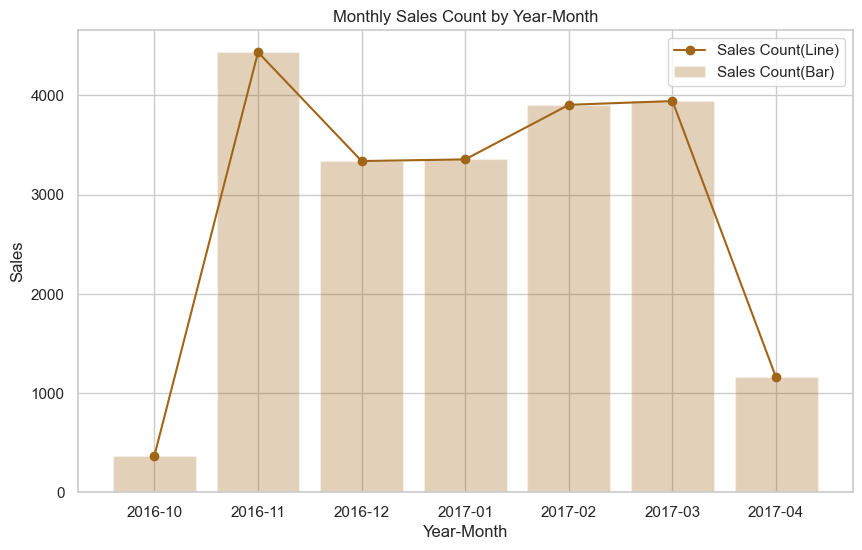

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(monthly_sales['year_month'].astype(str), monthly_sales['Transaction'], alpha=0.3, label='Sales Count(Bar)')
ax.plot(monthly_sales['year_month'].astype(str), monthly_sales['Transaction'], marker='o', label='Sales Count(Line)')

ax.set_xlabel('Year-Month')
ax.set_ylabel('Sales')
plt.title('Monthly Sales Count by Year-Month')
plt.legend()
plt.show()


> # period_day

In [ ]:
df['period_day'].unique()

array(['morning', 'afternoon', 'evening', 'night'], dtype=object)

- 시간대 : 아침 점심 저녁 밤

In [ ]:
for period in ['morning', 'afternoon', 'evening', 'night']:
    min_time = df[df['period_day'] == period]['date_time'].min()
    max_time = df[df['period_day'] == period]['date_time'].max()
    print(f"{period.capitalize()} - 시작: {min_time}, 종료: {max_time}")


Morning - 시작: 2016-10-30 09:58:00, 종료: 2017-04-09 11:59:00
Afternoon - 시작: 2016-10-30 12:00:00, 종료: 2017-04-09 15:04:00
Evening - 시작: 2016-10-31 17:06:00, 종료: 2017-04-07 17:30:00
Night - 시작: 2016-12-17 21:42:00, 종료: 2017-04-08 23:20:00


시간대별 매출상품 개수

In [ ]:
grouped = df.groupby(['period_day', df['date_time'].dt.hour])['Transaction'].count().reset_index()
grouped

,period_day,date_time,Transaction
0,afternoon,12,2854
1,afternoon,13,2617
2,afternoon,14,2640
3,afternoon,15,2115
4,afternoon,16,1343
5,evening,17,368
6,evening,18,82
7,evening,19,48
8,evening,20,22
9,morning,1,1


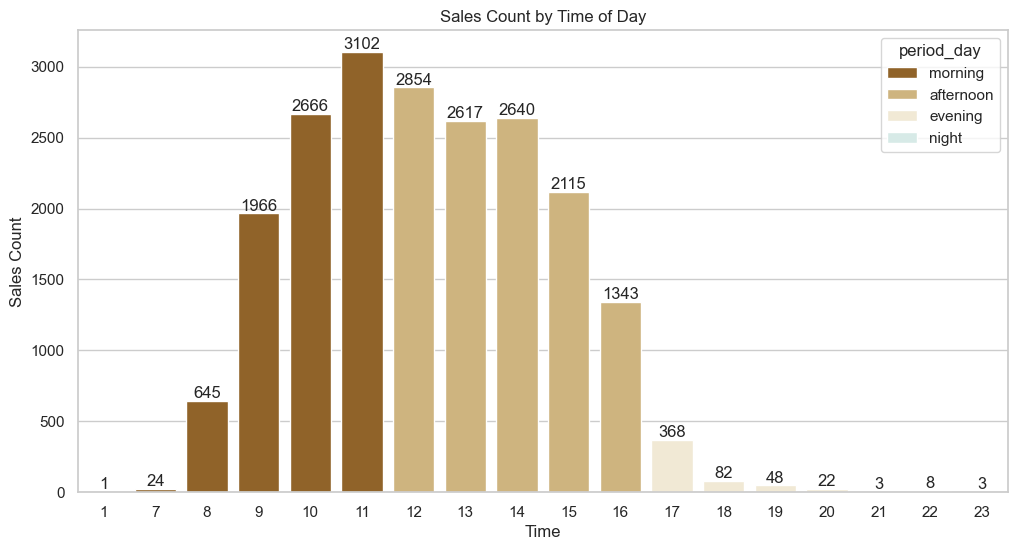

In [ ]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='date_time', y='Transaction', hue='period_day', data=grouped)
plt.title('Sales Count by Time of Day')
plt.xlabel('Time')
plt.ylabel('Sales Count')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])
ax.bar_label(ax.containers[3])
plt.show()

요일추가

In [ ]:
df['weekday'] = df['date_time'].dt.day_name()

In [ ]:
df['weekday']

0        Sunday
1        Sunday
2        Sunday
3        Sunday
4        Sunday
          ...  
20502    Sunday
20503    Sunday
20504    Sunday
20505    Sunday
20506    Sunday
Name: weekday, Length: 20507, dtype: object

요일별 개수

In [ ]:
df.groupby('weekday')['Transaction'].count()

weekday
Friday       3124
Monday       2324
Saturday     4605
Sunday       3095
Thursday     2646
Tuesday      2392
Wednesday    2321
Name: Transaction, dtype: int64

정렬 필요해보여 카테고리화해서 순서적용

In [ ]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday','Sunday',]

카테고리화

In [ ]:
df['weekday'] = pd.Categorical(df['weekday'], categories=weekday_order, ordered=True)

적용

In [ ]:
weekday_count = df.groupby('weekday')['Transaction'].count()
weekday_count

/var/folders/b8/3v2wwvpj5j90k29tbr4zfpbm0000gn/T/ipykernel_29734/1894573365.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekday_count = df.groupby('weekday')['Transaction'].count()


weekday
Monday       2324
Tuesday      2392
Wednesday    2321
Thursday     2646
Friday       3124
Saturday     4605
Sunday       3095
Name: Transaction, dtype: int64

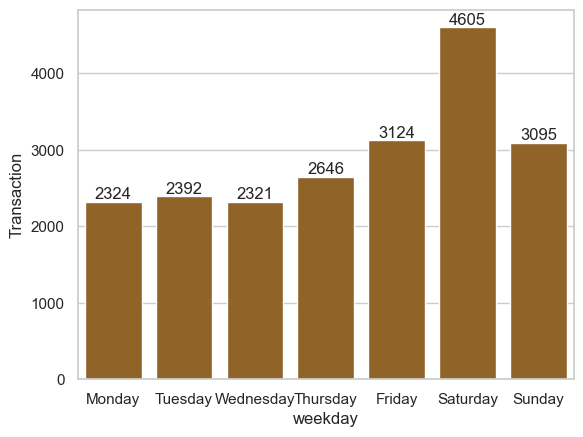

In [ ]:
ax = sns.barplot(x=weekday_count.index, y=weekday_count)
ax.bar_label(ax.containers[0])
plt.show()


- 정렬 완료
- 토요일에 가장 많은 상품이 판매됨

테블로로 시각화 하기위해 일단 파일 변환

In [ ]:
df.to_csv('bakery_file_teablu.csv', index=False)

# 알고리즘 사용전 그룹화

In [ ]:
bakery_df = df.groupby('Transaction')['Item'].agg(list).reset_index()

In [ ]:
bakery_df

,Transaction,Item
0,1,[Bread]
1,2,"[Scandinavian, Scandinavian]"
2,3,"[Hot chocolate, Jam, Cookies]"
3,4,[Muffin]
4,5,"[Coffee, Pastry, Bread]"
...,...,...
9460,9680,[Bread]
9461,9681,"[Truffles, Tea, Spanish Brunch, Christmas common]"
9462,9682,"[Muffin, Tacos-Fajita, Coffee, Tea]"
9463,9683,"[Coffee, Pastry]"


In [ ]:
te = TransactionEncoder()
te_result = te.fit_transform(bakery_df['Item'])

In [ ]:
te_df = pd.DataFrame(data=te_result, columns=te.columns_)
te_df

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9460,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9461,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
9462,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9463,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


___
# FP-Growth 알고리즘
***

In [ ]:
from mlxtend.frequent_patterns import fpgrowth, apriori

In [ ]:
frequent_itemset = fpgrowth(te_df, min_support=0.02, use_colnames=True).sort_values(by='support', ascending=False)
frequent_itemset

,support,itemsets
5,0.478394,(Coffee)
0,0.327205,(Bread)
8,0.142631,(Tea)
12,0.103856,(Cake)
19,0.090016,"(Coffee, Bread)"
6,0.086107,(Pastry)
13,0.071844,(Sandwich)
7,0.061807,(Medialuna)
2,0.058320,(Hot chocolate)
28,0.054728,"(Coffee, Cake)"


***
## 연관 규칙 추출 및 평가
***


In [ ]:
from mlxtend.frequent_patterns import association_rules

bakery_association_rules = association_rules(frequent_itemset, metric='confidence', min_threshold=0.02)
bakery_association_rules = bakery_association_rules.sort_values(by=['support','confidence','lift'], ascending=False)
bakery_association_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
1,(Bread),(Coffee),0.327205,0.478394,0.090016,0.275105,0.575059,-0.066517,0.719561,-0.523431
0,(Coffee),(Bread),0.478394,0.327205,0.090016,0.188163,0.575059,-0.066517,0.828731,-0.586210
3,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,0.005044,1.102664,0.102840
2,(Coffee),(Cake),0.478394,0.103856,0.054728,0.114399,1.101515,0.005044,1.011905,0.176684
5,(Tea),(Coffee),0.142631,0.478394,0.049868,0.349630,0.730840,-0.018366,0.802014,-0.300482
4,(Coffee),(Tea),0.478394,0.142631,0.049868,0.104240,0.730840,-0.018366,0.957142,-0.413856
7,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,0.006351,1.164682,0.146161
6,(Coffee),(Pastry),0.478394,0.086107,0.047544,0.099382,1.154168,0.006351,1.014740,0.256084
9,(Sandwich),(Coffee),0.071844,0.478394,0.038246,0.532353,1.112792,0.003877,1.115384,0.109205
8,(Coffee),(Sandwich),0.478394,0.071844,0.038246,0.079947,1.112792,0.003877,1.008807,0.194321


| 조건절   | 결과절   | support  | confidence | lift      | support 해석      | confidence 해석      | lift 해석      |
|---------|---------|----------|------------|-----------|-------------------|-----------------------|----------------|
| 빵      | 커피     | 0.090016 | 0.275105   | 0.575059  | 전체비율중 약 9%    | "빵"을 구매한 사람 중에서 "커피"를 함께 구매한 사람의 비율 27% | 두 상품 간의 연관성이 평균보다 낮음 (0.575059) |
| 커피     | 빵      | 0.090016 | 0.188163   | 0.575059  | 전체비율중 약 9%    | "커피"를 구매한 사람 중에서 "빵"을 함께 구매한 사람의 비율 19% | 두 상품 간의 연관성이 평균보다 낮음 (0.575059) |
| 케잌     | 커피     | 0.054728 | 0.526958   | 1.101515  | 전체비율중 약 5%    | "케잌"을 구매한 사람 중에서 "커피"를 함께 구매한 사람의 비율 53% | 두 상품 간의 연관성이 평균보다 높은 관계 (1.101515) |
| 커피     | 케잌     | 0.054728 | 0.114399   | 1.101515  | 전체비율중 약 5%    | "커피"를 구매한 사람 중에서 "케잌"을 함께 구매한 사람의 비율 11% | 두 상품 간의 연관성이 평균보다 높은 관계 (1.101515) |
| 차      | 커피     | 0.049868 | 0.349630   | 0.730840  | 전체비율중 약 5%    | "차"를 구매한 사람 중에서 "커피"를 함께 구매한 사람의 비율 35% | 두 상품 간의 연관성이 평균보다 낮음 (0.730840) |
| 커피     | 차      | 0.049868 | 0.104240   | 0.730840  | 전체비율중 약 5%    | "커피"를 구매한 사람 중에서 "차"를 함께 구매한 사람의 비율 10% | 두 상품 간의 연관성이 평균보다 낮음 (0.730840) |
| 파스타   | 커피     | 0.047544 | 0.552147   | 1.154168  | 전체비율중 약 5%    | "파스타"를 구매한 사람 중에서 "커피"를 함께 구매한 사람의 비율 55% | 두 상품 간의 연관성이 평균보다 높은 관계 (1.154168) |
| 커피     | 파스타   | 0.047544 | 0.099382   | 1.154168  | 전체비율중 약 5%    | "커피"를 구매한 사람 중에서 "파스타"를 함께 구매한 사람의 비율 10% | 두 상품 간의 연관성이 평균보다 높은 관계 (1.154168) |
| 샌드위치 | 커피     | 0.038246 | 0.532353   | 1.112792  | 전체비율중 약 4%    | "샌드위치"를 구매한 사람 중에서 "커피"를 함께 구매한 사람의 비율 53% | 두 상품 간의 연관성이 평균보다 높은 관계 (1.112792) |
| 커피     | 샌드위치 | 0.038246 | 0.079947   | 1.112792  | 전체비율중 약 4%    | "커피"를 구매한 사람 중에서 "샌드위치"를 함께 구매한 사람의 비율 8%  | 두 상품 간의 연관성이 평균보다 높은 관계 (1.112792) |


In [ ]:
bakery_association_rules.sort_values(by='support',ascending=False)[['antecedents','consequents','support']].head(5)

,antecedents,consequents,support
1,(Bread),(Coffee),0.090016
0,(Coffee),(Bread),0.090016
3,(Cake),(Coffee),0.054728
2,(Coffee),(Cake),0.054728
5,(Tea),(Coffee),0.049868


In [ ]:
bakery_association_rules.sort_values(by='confidence',ascending=False)[['antecedents','consequents','confidence']].head(5)

,antecedents,consequents,confidence
23,(Toast),(Coffee),0.704403
11,(Medialuna),(Coffee),0.569231
7,(Pastry),(Coffee),0.552147
27,(Juice),(Coffee),0.534247
9,(Sandwich),(Coffee),0.532353


In [ ]:
bakery_association_rules.sort_values(by='lift',ascending=False)[['antecedents','consequents','lift']].head(5)

,antecedents,consequents,lift
21,(Tea),(Cake),1.604781
20,(Cake),(Tea),1.604781
23,(Toast),(Coffee),1.472431
22,(Coffee),(Toast),1.472431
10,(Coffee),(Medialuna),1.189878


support (지지도) 클수록 규칙이 자주 발생  
confidence (신뢰도) 1에 가까울수록 규칙이 신뢰할만함(고객추천시 매우 유용)  
lift (향상도)   
- lift가 1이면 A와 B는 통계적으로 독립
- lift > 1은 A와 B 사이에 긍정적인 관계
- lift < 1은 A와 B 사이에 부정적인 관계  

In [ ]:
bakery_association_rules['antecedents'] = bakery_association_rules['antecedents'].apply(lambda x: ', '.join(list(x)) if isinstance(x, frozenset) else x)
bakery_association_rules['consequents'] = bakery_association_rules['consequents'].apply(lambda x: ', '.join(list(x)) if isinstance(x, frozenset) else x)


In [ ]:
bakery_association_rules.to_csv('processed_file.csv', index=False)

***
# PrefixSpan 알고리즘
***

In [ ]:
sequence_df = df
sequence_df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,Category,year_month,weekday
0,1,Bread,2016-10-30 09:58:00,morning,weekend,Bakery,2016-10,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,Events & Themes,2016-10,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,Events & Themes,2016-10,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,Beverages,2016-10,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,Snacks,2016-10,Sunday


In [ ]:
sequence_df = sequence_df.sort_values(by='Item', ascending=True)

In [ ]:
sequence_groupby = sequence_df.groupby(['Transaction', 'date_time', 'Category'])['Item'].agg(tuple).reset_index()
sequence_groupby

,Transaction,date_time,Category,Item
0,1,2016-10-30 09:58:00,Bakery,"(Bread,)"
1,2,2016-10-30 10:05:00,Events & Themes,"(Scandinavian, Scandinavian)"
2,3,2016-10-30 10:07:00,Beverages,"(Hot chocolate,)"
3,3,2016-10-30 10:07:00,Snacks,"(Cookies, Jam)"
4,4,2016-10-30 10:08:00,Bakery,"(Muffin,)"
...,...,...,...,...
15739,9682,2017-04-09 14:32:00,Beverages,"(Coffee, Tea)"
15740,9682,2017-04-09 14:32:00,Food,"(Tacos-Fajita,)"
15741,9683,2017-04-09 14:57:00,Bakery,"(Pastry,)"
15742,9683,2017-04-09 14:57:00,Beverages,"(Coffee,)"


In [ ]:
sequence_groupby = sequence_groupby.sort_values(by='date_time', ascending=True)
sequence_groupby2 = sequence_groupby.groupby('Transaction')['Item'].agg(list).reset_index()
sequence_groupby2

,Transaction,Item
0,1,"[(Bread,)]"
1,2,"[(Scandinavian, Scandinavian)]"
2,3,"[(Hot chocolate,), (Cookies, Jam)]"
3,4,"[(Muffin,)]"
4,5,"[(Bread, Pastry), (Coffee,)]"
...,...,...
9460,9680,"[(Bread,)]"
9461,9681,"[(Tea,), (Christmas common,), (Spanish Brunch,..."
9462,9682,"[(Coffee, Tea), (Muffin,), (Tacos-Fajita,)]"
9463,9683,"[(Coffee,), (Pastry,)]"


In [ ]:
sequence_groupby2['Item'].apply(lambda x: len(x) >= 2).sum()

np.int64(4866)

In [ ]:
from prefixspan import PrefixSpan
ps = PrefixSpan(sequence_groupby2['Item'])
ps.frequent(2) # 최소 지지도 2이상
ps.topk(7) # 빈발 시퀀스 Top 7

[(2807, [('Coffee',)]),
 (2087, [('Bread',)]),
 (690, [('Tea',)]),
 (660, [('Coffee', 'Coffee')]),
 (573, [('Cake',)]),
 (480, [('Sandwich',)]),
 (384, [('Cookies',)])]

___


# 카테고리별 FP-Growth

In [ ]:
df

,Transaction,Item,date_time,period_day,weekday_weekend,Category,year_month,weekday
0,1,Bread,2016-10-30 09:58:00,morning,weekend,Bakery,2016-10,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,Events & Themes,2016-10,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,Events & Themes,2016-10,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,Beverages,2016-10,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,Snacks,2016-10,Sunday
...,...,...,...,...,...,...,...,...
20502,9682,Coffee,2017-04-09 14:32:00,afternoon,weekend,Beverages,2017-04,Sunday
20503,9682,Tea,2017-04-09 14:32:00,afternoon,weekend,Beverages,2017-04,Sunday
20504,9683,Coffee,2017-04-09 14:57:00,afternoon,weekend,Beverages,2017-04,Sunday
20505,9683,Pastry,2017-04-09 14:57:00,afternoon,weekend,Bakery,2017-04,Sunday


데이터프레임에서 Transaction을 기준으로 카테고리 데이터를 그룹화

In [ ]:
transactions = df.groupby('Transaction')['Category'].apply(list).tolist()

In [ ]:
transactions

[['Bakery'],
 ['Events & Themes', 'Events & Themes'],
 ['Beverages', 'Snacks', 'Snacks'],
 ['Bakery'],
 ['Beverages', 'Bakery', 'Bakery'],
 ['Bakery', 'Bakery', 'Bakery'],
 ['Bakery', 'Bakery', 'Beverages', 'Beverages'],
 ['Bakery', 'Bakery'],
 ['Bakery', 'Bakery'],
 ['Events & Themes', 'Bakery'],
 ['Bakery', 'Bakery', 'Bakery'],
 ['Snacks', 'Beverages', 'Bakery', 'Bakery', 'Beverages'],
 ['Dining Sets & Accessories', 'Bakery', 'Beverages'],
 ['Bakery', 'Bakery', 'Bakery'],
 ['Beverages', 'Events & Themes'],
 ['Bakery', 'Bakery', 'Beverages'],
 ['Beverages'],
 ['Bakery'],
 ['Bakery', 'Bakery'],
 ['Bakery', 'Bakery'],
 ['Beverages', 'Beverages', 'Bakery', 'Bakery'],
 ['Snacks'],
 ['Events & Themes', 'Bakery'],
 ['Bakery'],
 ['Events & Themes'],
 ['Snacks'],
 ['Events & Themes'],
 ['Beverages', 'Bakery'],
 ['Bakery', 'Snacks'],
 ['Bakery'],
 ['Dining Sets & Accessories'],
 ['Events & Themes', 'Bakery'],
 ['Beverages'],
 ['Beverages', 'Bakery'],
 ['Bakery', 'Events & Themes'],
 ['Beverage

In [ ]:
# Transaction 데이터를 One-Hot Encoding 형식으로 변환
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# FP-Growth 알고리즘 실행 (최소 지지도 설정)
frequent_itemsets = fpgrowth(df_encoded, min_support=0.05, use_colnames=True)

# 결과 확인
frequent_itemsets.sort_values(by='support',ascending=False)

,support,itemsets
2,0.626096,(Beverages)
0,0.602853,(Bakery)
5,0.305335,"(Beverages, Bakery)"
3,0.271844,(Snacks)
6,0.180032,"(Snacks, Beverages)"
7,0.129952,"(Snacks, Bakery)"
4,0.084628,(Food)
8,0.081669,"(Snacks, Beverages, Bakery)"
9,0.063180,"(Beverages, Food)"
1,0.057052,(Events & Themes)


In [ ]:
# 연관 규칙 생성
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# 연관 규칙 확인
rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(Bakery),(Beverages),0.602853,0.626096,0.305335,0.506484,0.808956,-0.072108,0.757633,-0.372900
1,(Snacks),(Beverages),0.271844,0.626096,0.180032,0.662262,1.057764,0.009831,1.107082,0.074997
2,"(Snacks, Bakery)",(Beverages),0.129952,0.626096,0.081669,0.628455,1.003768,0.000307,1.006350,0.004315
3,(Food),(Beverages),0.084628,0.626096,0.063180,0.746567,1.192416,0.010195,1.475355,0.176285


___

# 시간대별 FP-Growth

In [ ]:
df

,Transaction,Item,date_time,period_day,weekday_weekend,Category,year_month,weekday
0,1,Bread,2016-10-30 09:58:00,morning,weekend,Bakery,2016-10,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,Events & Themes,2016-10,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,Events & Themes,2016-10,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,Beverages,2016-10,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,Snacks,2016-10,Sunday
...,...,...,...,...,...,...,...,...
20502,9682,Coffee,2017-04-09 14:32:00,afternoon,weekend,Beverages,2017-04,Sunday
20503,9682,Tea,2017-04-09 14:32:00,afternoon,weekend,Beverages,2017-04,Sunday
20504,9683,Coffee,2017-04-09 14:57:00,afternoon,weekend,Beverages,2017-04,Sunday
20505,9683,Pastry,2017-04-09 14:57:00,afternoon,weekend,Bakery,2017-04,Sunday


In [ ]:
# period_day별 거래 데이터를 리스트로 변환
transactions_by_period = {}
for period in df['period_day'].unique():
    transactions = df[df['period_day'] == period].groupby('Transaction')['Category'].apply(list).tolist()
    transactions_by_period[period] = transactions

# 각 시간대별 거래 수 확인
for period, transactions in transactions_by_period.items():
    print(f"{period} 시간대 거래 수: {len(transactions)}")

morning 시간대 거래 수: 4103
afternoon 시간대 거래 수: 5089
evening 시간대 거래 수: 261
night 시간대 거래 수: 12


In [ ]:
# 시간대별 FP-Growth 실행
for period, transactions in transactions_by_period.items():
    print(f"\n=== {period} 시간대 연관 규칙 분석 ===")

    # TransactionEncoder를 사용해 데이터 변환
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

    # FP-Growth 적용
    frequent_itemsets = fpgrowth(df_encoded, min_support=0.05, use_colnames=True)
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

    # 연관 규칙 출력
    print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])



=== morning 시간대 연관 규칙 분석 ===
           antecedents  consequents   support  confidence      lift
0          (Beverages)     (Bakery)  0.323909    0.523847  0.789040
1             (Snacks)  (Beverages)  0.124056    0.671504  1.086000
2             (Snacks)     (Bakery)  0.102120    0.552770  0.832605
3  (Snacks, Beverages)     (Bakery)  0.063368    0.510806  0.769396
4     (Snacks, Bakery)  (Beverages)  0.063368    0.620525  1.003553

=== afternoon 시간대 연관 규칙 분석 ===
        antecedents  consequents   support  confidence      lift
0          (Snacks)  (Beverages)  0.226567    0.660367  1.032127
1  (Snacks, Bakery)  (Beverages)  0.096876    0.629630  0.984086
2          (Bakery)  (Beverages)  0.295932    0.526205  0.822438
3            (Food)  (Beverages)  0.099627    0.736919  1.151775

=== evening 시간대 연관 규칙 분석 ===
        antecedents  consequents   support  confidence      lift
0          (Snacks)  (Beverages)  0.160920    0.608696  1.212745
1  (Snacks, Bakery)  (Beverages)  0.076628   

# 시간대별 PrefixSpan

In [ ]:
from prefixspan import PrefixSpan

# 시간대별 순차 데이터 준비
sequences_by_period = {}
for period in df['period_day'].unique():
    sequences = df[df['period_day'] == period].groupby('Transaction')['Category'].apply(list).tolist()
    sequences_by_period[period] = sequences

# PrefixSpan 적용 및 결과 확인
for period, sequences in sequences_by_period.items():
    print(f"\n=== {period} 시간대 Sequential Pattern ===")
    ps = PrefixSpan(sequences)
    patterns = ps.frequent(2)  # 최소 출현 횟수 설정 (2번 이상 등장한 패턴)
    print(ps.topk(10)) # 빈발 시퀀스 Top 7




=== morning 시간대 Sequential Pattern ===
[(2724, ['Bakery']), (2537, ['Beverages']), (987, ['Beverages', 'Bakery']), (782, ['Beverages', 'Beverages']), (777, ['Bakery', 'Bakery']), (758, ['Snacks']), (501, ['Bakery', 'Beverages']), (376, ['Beverages', 'Snacks']), (340, ['Beverages', 'Beverages', 'Bakery']), (275, ['Bakery', 'Snacks'])]

=== afternoon 시간대 Sequential Pattern ===
[(3256, ['Beverages']), (2862, ['Bakery']), (1746, ['Snacks']), (1140, ['Beverages', 'Beverages']), (1099, ['Beverages', 'Bakery']), (833, ['Beverages', 'Snacks']), (688, ['Food']), (636, ['Bakery', 'Bakery']), (542, ['Bakery', 'Beverages']), (477, ['Bakery', 'Snacks'])]

=== evening 시간대 Sequential Pattern ===
[(131, ['Beverages']), (113, ['Bakery']), (69, ['Snacks']), (45, ['Beverages', 'Beverages']), (43, ['Events & Themes']), (38, ['Beverages', 'Bakery']), (34, ['Beverages', 'Snacks']), (29, ['Bakery', 'Bakery']), (25, ['Bakery', 'Beverages']), (23, ['Dining Sets & Accessories'])]

=== night 시간대 Sequential Patt